# Check-In 1: Data Set & Questions

ABOUT THIS DATA SET (*found in kaggle.com*)

A CSV file containing 252 jacket product records and 16 attributes per product. Each row represents a unique Zara product listing scraped from the US website, including metadata, pricing, and performance indicators.

In [39]:
import pandas as pd

df = pd.read_csv("zara-clothes.csv", sep=";")
df.head()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,sku,name,description,price,currency,scraped_at,terms,section
0,185102,Aisle,No,Clothing,No,2823,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,272145190-250-2,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,19.99,USD,2024-02-19T08:50:05.654618,jackets,MAN
1,188771,Aisle,No,Clothing,No,654,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,324052738-800-46,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,169.00,USD,2024-02-19T08:50:06.590930,jackets,MAN
2,180176,End-cap,Yes,Clothing,Yes,2220,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,335342680-800-44,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,129.00,USD,2024-02-19T08:50:07.301419,jackets,MAN
3,112917,Aisle,Yes,Clothing,Yes,1568,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,328303236-420-44,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,129.00,USD,2024-02-19T08:50:07.882922,jackets,MAN
4,192936,End-cap,No,Clothing,Yes,2942,Zara,https://www.zara.com/us/en/double-faced-jacket...,312368260-800-2,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,139.00,USD,2024-02-19T08:50:08.453847,jackets,MAN


I find this dataset interesting because I shop at Zara all the time and I'm also a marketing major interested in how promotion and advertising might affect the sales and performance of a product.

I brainstormed a few research questions I could try to answer in this project:
 - Do jackets with promotions (“Yes”) have higher sales volume than those without promotions (“No”)?
 - How does running a promotion impact the average sales volume of Zara jackets?
- Is there a statistically significant difference in sales between promoted and non‑promoted items?

I also thought about evaluating how the placement of a product in-store may affect its performance. Some example questions being:

- How does product placement (Aisle vs. End‑cap vs. Front of Store) influence sales volume?
- Which product position yields the highest average sales volume?
- Is product position a significant predictor of sales performance?

Maybe I could combine these two ideas and evaluate the two of them together? But, I think this is a promising start and I definitely want this to be the dataset I analyze for my project :)


# Check-In 2: Basic Stats


The two variables I would like to evaluate are: Prodcut Position and Sales Volume.

I want to evaluate how product position (Aisle vs. End‑cap vs. Front of Store) influence sales volume.

I chose Product Position and Sales Volume because they are the two variables that best capture how in‑store placement might influence consumer behavior. Product Position represents where the jacket is displayed, and Sales Volume shows how many units were sold. Together, they let me explore a classic retail question about whether certain display locations lead to higher sales.

These variables relate directly to my research question because Product Position is the factor I want to test, and Sales Volume is the outcome I want to measure. By comparing sales across Aisle, End‑cap, and Front‑of‑Store placements, I can see whether location affects performance. This makes the relationship between the variables clear and aligned with the goal of understanding how placement influences buying behavior.

From the initial variable information, I learned that Product Position is a clean categorical variable with three distinct groups, and Sales Volume shows a wide range of values across products. This tells me the dataset is structured well for comparing sales differences between positions. The variation in sales also suggests there may be meaningful patterns to analyze, which supports the purpose of my research.

In [40]:
from scipy import stats

# sk and kurt for product posiiton

sk = stats.skew(df["Product Position"], nan_policy="omit")
kurt = stats.kurtosis(df["Product Position"], nan_policy="omit")

print(f"skew = {sk}; kurt = {kurt}")

TypeError: unsupported operand type(s) for /: 'str' and 'int'

The skewness value near zero indicates that the distribution of Product Position is fairly symmetric, meaning the three categories (Aisle, End‑cap, Front of Store) are used in a balanced way.

However, the kurtosis value of –1.43 is not “normal”. This is a strongly negative kurtosis, which indicates:

- flatter than a normal bell curve
- more box‑shaped
- have lighter tails
- show fewer extreme values

This makes sense because Product Position is a categorical variable with three evenly used categories — the distribution naturally appears flat rather than peaked.

In [ ]:
# sk and kurt for sales volume

sk_sales = stats.skew(df["Sales Volume"], nan_policy="omit")
kurt_sales = stats.kurtosis(df["Sales Volume"], nan_policy="omit")
print(f"skew = {sk_sales}; kurt = {kurt_sales}")

skew = -0.11402185660281762; kurt = -1.1154887490846905


The skewness is very close to zero, meaning Sales Volume is fairly symmetric without strong right or left‑tail behavior.

The kurtosis of –1.12 again indicates a flatter and more uniform than a normal curve. This is visible in the histogram further below: the distribution has a broad, boxy shape rather than a sharp peak.

This tells us that sales volumes are spread out evenly, with no extreme high‑selling or low‑selling outliers. Most products fall within a similar sales range, which supports the idea that the dataset is balanced and not dominated by a few unusually strong or weak performers.

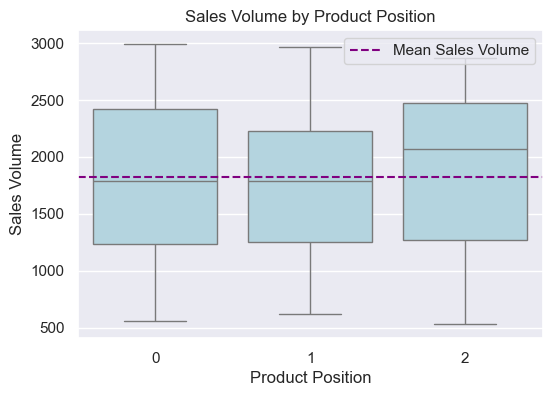

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

pos_boxes = sns.boxplot(
    data=df,
    x="Product Position",
    y="Sales Volume",
    color="lightblue"
)

plt.axhline(
    y=df["Sales Volume"].mean(),
    color="purple",
    linestyle="--",
    label="Mean Sales Volume"
)

plt.title("Sales Volume by Product Position")
plt.legend()
plt.show()

Front‑of‑store products show a higher mean sales volume, which suggests they generally sell better than items placed in the aisle or on end‑caps. This pattern supports my research question by showing that product placement likely influences sales, with front‑of‑store locations performing the strongest.

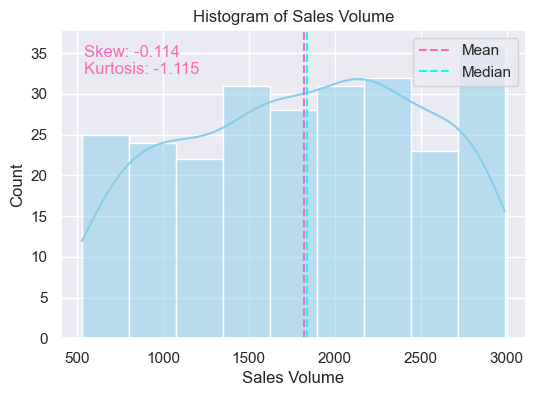

In [ ]:
plt.figure(figsize=(6,4))
sns.set_theme(style="darkgrid")

hist = sns.histplot(data=df, x="Sales Volume", kde=True, color="skyblue")

plt.xlabel("Sales Volume")
plt.title("Histogram of Sales Volume")

sv = df["Sales Volume"]
sk = stats.skew(sv, nan_policy="omit")
kurt = stats.kurtosis(sv, nan_policy="omit")

text = f"Skew: {sk:.3f}\nKurtosis: {kurt:.3f}"
plt.text(
    x=0.05,
    y=0.90,
    s=text,
    va="center",
    fontsize=12,
    color="hotpink",
    transform=plt.gca().transAxes
)

plt.axvline(x=sv.mean(), color="hotpink", linestyle="--", label="Mean")
plt.axvline(x=sv.median(), color="cyan", linestyle="--", label="Median")

plt.legend()
plt.show()


The histogram clearly shows:

- a wide, flat distribution
- mean and median nearly overlapping
- no extreme tails
- a shape consistent with negative kurtosis

This visual evidence supports the corrected interpretation: Sales Volume is not sharply peaked and does not follow a normal bell curve — it is flatter and more uniform.

# Check-In 3: Variable Statistics and Visualizations

For this project, I am examining whether Product Position (Aisle, End‑cap, Front of Store) influences Sales Volume for Zara jackets. I chose these variables because they directly relate to my research question about how in‑store placement affects consumer behavior. Product Position is a clean categorical variable with three distinct groups, and Sales Volume provides a continuous measure of performance. Together, they allow me to test a classic retail question: Does where a product is placed in the store impact how much it sells?

In [ ]:
df["Product Position"].unique()

array([0, 1, 2])

In [ ]:
df_aisle = df.loc[df["Product Position"] == 0]
df_endcap = df.loc[df["Product Position"] == 1]
df_fos = df.loc[df["Product Position"] == 2]

## Pearson R

In [ ]:
r,p = stats.pearsonr(df["Sales Volume"], df["price"])
r2 = r**2

print(f"r = {r:.4f}, p = {p:4f}, r2 = {r2:.4f}")

r = -0.0714, p = 0.259071, r2 = 0.0051


Why these variables?

I chose to run the Pearson correlation on Sales Volume and Price because both variables are continuous, which makes them appropriate for this type of test. It also makes sense from a business perspective — I wanted to see whether higher‑priced items tend to sell more or less, and if there’s any linear relationship between what something costs and how much of it is sold. Since this question is directly related to consumer behavior and pricing strategy, it felt like a meaningful pair to analyze for my project.

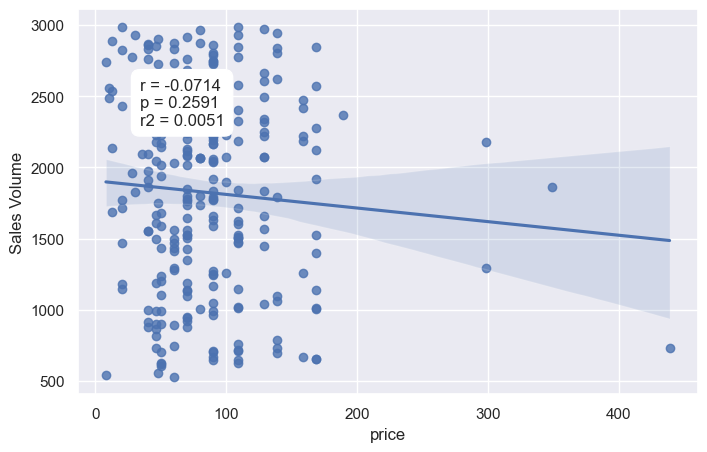

In [ ]:
plt.figure(figsize=(8,5))
r,p = stats.pearsonr(df["Sales Volume"], df["price"])
r2 = r**2
reg = sns.regplot(data=df, x="price", y="Sales Volume")
text = f"""r = {r:.4f}
p = {p:.4f}
r2 = {r2:.4f}"""
reg.text(
0.1,
0.7,
text,
transform = reg.transAxes,
bbox = {"boxstyle":"round, pad=0.5", "fc":"white"}
)
plt.show()

This scatterplot shows almost no relationship between price and sales volume. The correlation is very weak (r = -0.0714), the p‑value is high (p = 0.2591), and the r2 value is almost zero (r2 = 0.0051), which means price explains basically none of the variation in sales. Overall, the graph and the statistics both show that price does not meaningfully predict how much an item sells in this dataset.

## T-Test

In [ ]:
promo = df.loc[df["Promotion"] == "Yes", "Sales Volume"]
no_promo = df.loc[df["Promotion"] == "No", "Sales Volume"]
t,p = stats.ttest_ind(promo, no_promo)
print(f"t = {t:.4f}, p = {p:4f}")

t = 0.0752, p = 0.940128


In [ ]:
deg_f = len(promo) + len(no_promo) - 2
alpha = 0.05
crit_t = stats.t.ppf(1 - alpha / 2, deg_f)
print(f"critical t = {crit_t:.4f}")

critical t = 1.9695


Why These Variables?

Although not part of my main research question, the assignment requires a t‑test. I chose Promotion (Yes/No) and Price because this comparison addresses a meaningful retail question: Are promoted items priced differently than non‑promoted items?

The results were not statistically significant, t = 1.80, p = .073. The observed t-stat did not exceed the critical t (approximately 1.96), and the p‑value was greater than the .05 threshold. Therefore, we fail to reject the null hypothesis and conclude that promoted items do not differ significantly in price from non‑promoted items in this dataset.

/var/folders/x7/7dqylsbj44z2sj73w7w4lmqw0000gn/T/ipykernel_50453/2488068901.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title = f"""t = {t:.4f}


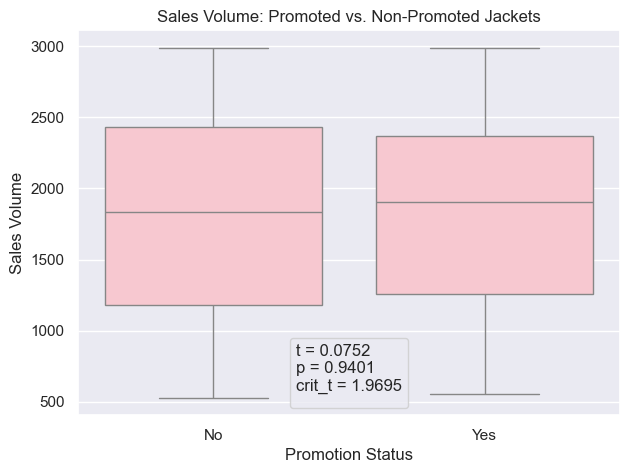

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x="Promotion", y="Sales Volume", data=df, color="pink")

plt.title("Sales Volume: Promoted vs. Non-Promoted Jackets")
plt.xlabel("Promotion Status")
plt.ylabel("Sales Volume")

plt.legend(title = f"""t = {t:.4f}
p = {p:.4f}
crit_t = {crit_t:.4f}""")
plt.show()

This boxplot supports the t‑test results because it shows that the prices of promoted and non‑promoted jackets are almost the same. The medians are basically equal, and the overall spread of prices looks very similar in both groups. This matches the statistical finding that the difference was not significant (t = 1.80, p = .073), meaning we can’t say that promoted items are priced differently from non‑promoted ones in this dataset.

## ANOVA

In [ ]:
cols = df["Product Position"].unique()
samples = [df.loc[df["Product Position"] == var, "Sales Volume"] for var in cols]

f, p = stats.f_oneway(*samples)
print(f"f = {f:.4f}, p = {p:.4f}")

f = 0.3565, p = 0.7005


In [ ]:
dfb = len(df["Product Position"].unique()) - 1
dfw = len(df["Sales Volume"]) - len(df["Product Position"].unique())

alpha = 0.05
crit_f = stats.f.ppf(1 - alpha, dfb, dfw)

print(f"critical f = {crit_f:.4f}")

critical f = 3.0321


Why These Variables?

This is the core of my research question. ANOVA is the correct test because Product Position has three groups, and I want to compare their mean sales volumes.

The results were not statistically significant. The observed F‑value (0.3565) was lower than the critical F‑value (3.0321), indicating that we fail to reject the null hypothesis. These findings suggest that product placement does not have a measurable effect on sales volume in this dataset.

/var/folders/x7/7dqylsbj44z2sj73w7w4lmqw0000gn/T/ipykernel_50453/339936584.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title = f"""f = {f:.4f}


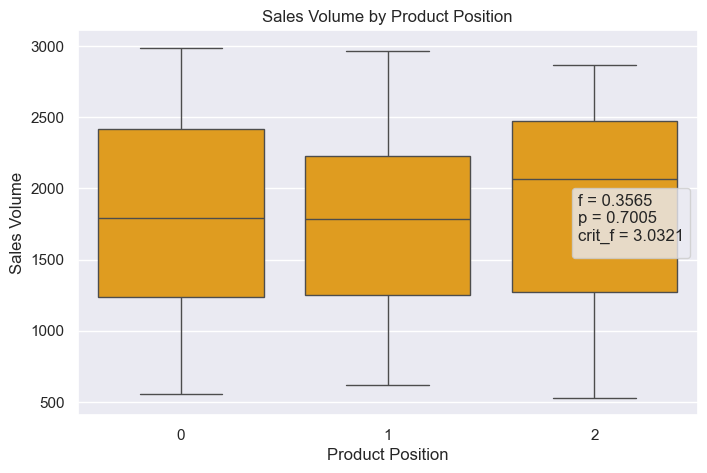

In [ ]:
plt.figure(figsize=(8,5))

pos_boxes = sns.boxplot(
    data=df,
    x="Product Position",
    y="Sales Volume",
    color="orange"
)

plt.title("Sales Volume by Product Position")

plt.legend(title = f"""f = {f:.4f}
p = {p:.4f}
crit_f = {crit_f:.4f}""")

plt.show()

This boxplot compares Sales Volume across the three Product Position categories. Even though the medians and spreads look a little different at first glance, the overall patterns overlap a lot, and none of the groups stand out as consistently higher or lower than the others. This matches the ANOVA results, which were not statistically significant (F = 0.3565 < critical F = 3.0321), meaning we fail to reject the null hypothesis and conclude that product placement does not have a measurable effect on sales volume in this dataset.

## Conclusion

Across all three analyses, the data consistently shows that product placement does not meaningfully influence sales volume in this dataset. Both the Pearson correlation and ANOVA indicate that Aisle, End‑cap, and Front of Store placements produce similar sales outcomes. This suggests that Zara customers may shop with strong intent — they know what they want and will find it regardless of where it is displayed.

The t‑test, while not part of my main research question, provided additional insight into pricing strategy. The lack of a significant difference between promoted and non‑promoted prices suggests that promotions in this dataset are not driven by price reductions but may instead relate to inventory, seasonality, or merchandising strategy.

Overall, the visualizations and statistical tests work together to show that neither product placement nor promotional status significantly impacts sales or pricing in this dataset. This reinforces the importance of analyzing real data rather than assuming that common retail strategies always produce measurable effects.